## EDA - Problema de Clasificación de Churn

In [2]:
# Data Overview
# Missings
# Outliers
# Distribuciones de los features numéricos
# Distribuciones de los features categóricas
# Análisis del Target
# Correlaciones (pearson, spearman)
# Mutual information
# VIF
# IV
# PSI de negocio
# Guardado de eda.yaml + insights EDA
# Guardado con MLFLOW

In [3]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_datetime64_any_dtype
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor


### Configuración del Proyecto

In [4]:
## Carpetas donde se guardaran los artefactos generados del EDA
NOMBRE_PROYECTO = 'Proyecto_Ejemplo_01'
ARTIFACTS_PATH = f'../proyectos_realizados/{NOMBRE_PROYECTO}/artifacts/eda'

Data Overview - Automatización

In [5]:
dataframe = pd.read_csv('./customer_churn_temporal_dataset.csv',
                        parse_dates= ['period'])
dataframe.head(5)

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,payment_method,late_payments,marketing_emails_opened,active_days_last_month,churn
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,BankTransfer,0,0,19,0
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,BankTransfer,1,1,21,0
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,BankTransfer,0,0,23,0
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,BankTransfer,0,3,29,0
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,BankTransfer,0,0,20,0


In [6]:
dataframe = dataframe.sort_values(by=['customer_id', 'period'], ascending= [True, True])
df_train = dataframe.loc[dataframe['period'] < '2025-01-01'].sort_values(by= ['customer_id', 'period'], ascending= [True, True])
df_test = dataframe.loc[(dataframe['period'] > '2024-12-01') & (dataframe['period'] < '2026-01-01')].sort_values(by= ['customer_id', 'period'], ascending= [True, True])
df_oot = dataframe.loc[(dataframe['period'] > '2025-12-01') & (dataframe['period'] < '2027-01-01')].sort_values(by= ['customer_id', 'period'], ascending= [True, True])


In [12]:
def get_first_datetime(data: pd.DataFrame):
    datetime_cols = data.select_dtypes(include='datetime')
    return None if datetime_cols.empty else datetime_cols.iloc[:,0]


def data_overview(data: pd.DataFrame, target_name, tipo_problema: str):
    filas = data.shape[0] # filas
    columnas = data.shape[1] # columnas
    # Features numéricas
    feat_num = data.select_dtypes(
        include= 'number'
    ).shape[1]
    # Features categóricas
    feat_cat = data.select_dtypes(
        include= ['string', 'category', 'object']
    ).shape[1]
    # Features Datetime
    feat_datetime = data.select_dtypes(
        include= 'datetime'
    ).shape[1]
    # Features booleanas
    feat_boolean = data.select_dtypes(
        include= 'bool'
    ).shape[1]
    # Missing Global
    missing_global = data.isnull().sum().sum()
    missing_ratio = (
        missing_global / data.size
    ) * 100
    # Feature con Missing
    feat_w_miss = (data.isnull().sum()>0).sum()
    # Feature con Missing > 20%
    feat_w_miss_0_20 = (data.isnull().sum()>0.2).sum()
    # Filas Duplicadas
    duplicados = data.duplicated().sum()
    # Features Constantes
    feat_constantes = (data.nunique()==1).sum()
    # Features casi constantes
    feat_casi_constantes = (data.nunique()==2).sum()
    # Features alta cardinalidad
    feat_alta_cardinalidad = (
        data.select_dtypes(include= ['string', 'category', 'object'])
        .nunique()>20).sum()
    # Features baja cardinalidad
    feat_baja_cardinalidad = (data.select_dtypes(
        include= ['object', 'string', 'category']
    ).nunique()<20).sum()
    # Tipo de Problema
    tipo_problema = tipo_problema
    # Target
    target = target_name
    # Target Rate (%)
    target_rate = f'{(data[target_name].mean()*100):.2f}%'
    # Ratio Desbalanceo
    ###
    # No event rate (%)
    no_event_rate = f'{((data[target_name] == 0).mean()*100):.2f}%'
    # Ratio Desbalanceo
    ###
    ratio_desbalanceo = round(((data[target_name] == 0).mean()) / (data[target_name].mean()), 0)

    fecha = get_first_datetime(data)
    if fecha is None:
        fecha_min = fecha_max = periodos = 'No disponible'
    else:
        # Fecha Min
        fecha_min = data.select_dtypes(include= 'datetime').iloc[:,0].min()
        # Fecha MAX
        fecha_max = data.select_dtypes(include= 'datetime').iloc[:,0].max()
        # Períodos
        periodos = (
            (fecha_max.year - fecha_min.year) * 12 +
            (fecha_max.month - fecha_min.month) + 1
        )
    df_data_overview = pd.DataFrame({
        'Filas': filas,
        'Columnas': columnas,
        'Features Numéricas': feat_num,
        'Features Categóricas': feat_cat,
        'Features Datetime': feat_datetime,
        'Features Booleanas': feat_boolean,
        'Missing Global (%)': missing_global,
        'Features con Missing': feat_w_miss,
        'Features > 20% Missing': feat_w_miss_0_20,
        'Filas Duplicadas': duplicados,
        'Features Constantes': feat_constantes,
        'Features Casi Constantes': feat_casi_constantes,
        'Features Alta Cardinalidad': feat_alta_cardinalidad,
        'Features Baja Cardinalidad': feat_baja_cardinalidad,
        'Tipo Problema': tipo_problema,
        'Target': target_name,
        'Target Rate (%)': target_rate,
        'No event Rate (%)': no_event_rate,
        'Ratio Desbalanceo': ratio_desbalanceo,
        'Fecha Min': fecha_min,
        'Fecha Max': fecha_max,
        'N° Períodos': periodos 
    }, index= ['Data Overview'])
    return df_data_overview.T


In [14]:
def inventario_features(data: pd.DataFrame):
    feats = []
    dtypes = []
    missing_pct = []
    unique_values = []
    cardinality_group = []
    is_constant = []
    is_near_constant = []
    semantic_type = []

    for i in data.columns:
        feats.append(i)
        dtypes.append(data[i].dtype.name)
        missing_pct.append(f'{((data[i].isnull().sum() / data[i].shape[0])*100):.2f}%')
        #unique_value = 
        unique_values.append(data[i].nunique())
        if data[i].dtype.name in ['object', 'category', 'str', 'bool']:
            if data[i].nunique() <= 20:
                cardinality_group.append('Bajo')
            elif data[i].nunique() <= 50:
                cardinality_group.append('Medio')
            else:
                cardinality_group.append('Alto')
        else:
            cardinality_group.append('---')
        if data[i].nunique() == 1:
            is_constant.append(True)
        else:
            is_constant.append(False)
        if data[i].nunique() == 2:
            is_near_constant.append(True)
        else:
            is_near_constant.append(False)
        ## Semantic Type
        if is_numeric_dtype(data[i]):
            value = (
                (data[i] % 1 == 0).all() # todos enteros
                and (data[i].min() >= 0)
                and (data[i].nunique() <= 30)
                and (data[i].quantile(0.99) <= 100)
                and (data[i] <= 2).mean() >= 0.4
            )
            if value:
                semantic_type.append('Conteo')
            else:
                semantic_type.append('Continua')
        elif is_string_dtype(data[i]):
            semantic_type.append('String')
        elif is_datetime64_any_dtype(data[i]):
            semantic_type.append('Datetime')


    return pd.DataFrame({
        'feature': feats,
        'dtype': dtypes,
        'semantic_dtype': semantic_type,
        'missing_pct': missing_pct,
        'unique_values': unique_values,
        'cardinality_group': cardinality_group,
        'is_constant': is_constant,
        'is_near_constant': is_near_constant
    }).sort_values(by= ['missing_pct', 'dtype'], ascending= [False, False])



In [15]:
inv_feat = inventario_features(data= dataframe)
inv_feat

,feature,dtype,semantic_dtype,missing_pct,unique_values,cardinality_group,is_constant,is_near_constant
0,customer_id,str,String,0.00%,3000,Alto,False,False
4,region,str,String,0.00%,6,Bajo,False,False
5,contract_type,str,String,0.00%,4,Bajo,False,False
10,payment_method,str,String,0.00%,5,Bajo,False,False
2,tenure_months,int64,Continua,0.00%,70,---,False,False
3,age,int64,Continua,0.00%,52,---,False,False
8,support_calls,int64,Conteo,0.00%,8,---,False,False
9,complaints_last_3m,int64,Conteo,0.00%,5,---,False,False
11,late_payments,int64,Conteo,0.00%,3,---,False,False
12,marketing_emails_opened,int64,Conteo,0.00%,10,---,False,False


In [20]:
def missings_analisis(data: pd.DataFrame):
    # Missings
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize = (10, 12))
    axes = ax.flatten()

    sns.heatmap(
        data= data.isnull().transpose(),
        cmap= 'YlGnBu',
        cbar_kws = {'label': 'Valores perdidos'},
        ax= axes[0]
    )
    axes[0].set_title('Distribución de valores perdidos')

    msno.heatmap(
        df= data,
        cmap= 'RdYlGn',
        figsize= (10,5),
        fontsize= 12,
        ax = axes[1]
    )
    axes[1].set_title('Correlación de nulidad entre variables')

    missing_list = data.columns.tolist()
    cant_missing = [data[feat].isnull().sum() for feat in data.columns.tolist()]
    data_missing = pd.DataFrame({
        'feat': missing_list,
        'cant_missing': cant_missing
    })
    data_missing = (
    data_missing[data_missing["cant_missing"] > 0]
    .sort_values("cant_missing", ascending=False)
    )
    axes[2].bar(
        data_missing['feat'],
        data_missing['cant_missing'],
    )
    axes[2].tick_params(axis = 'x', rotation = 45, labelsize = 7)
    axes[2].set_title('Cantidad de Missing por Feature')
    plt.tight_layout()
    plt.close(fig)

    return fig

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


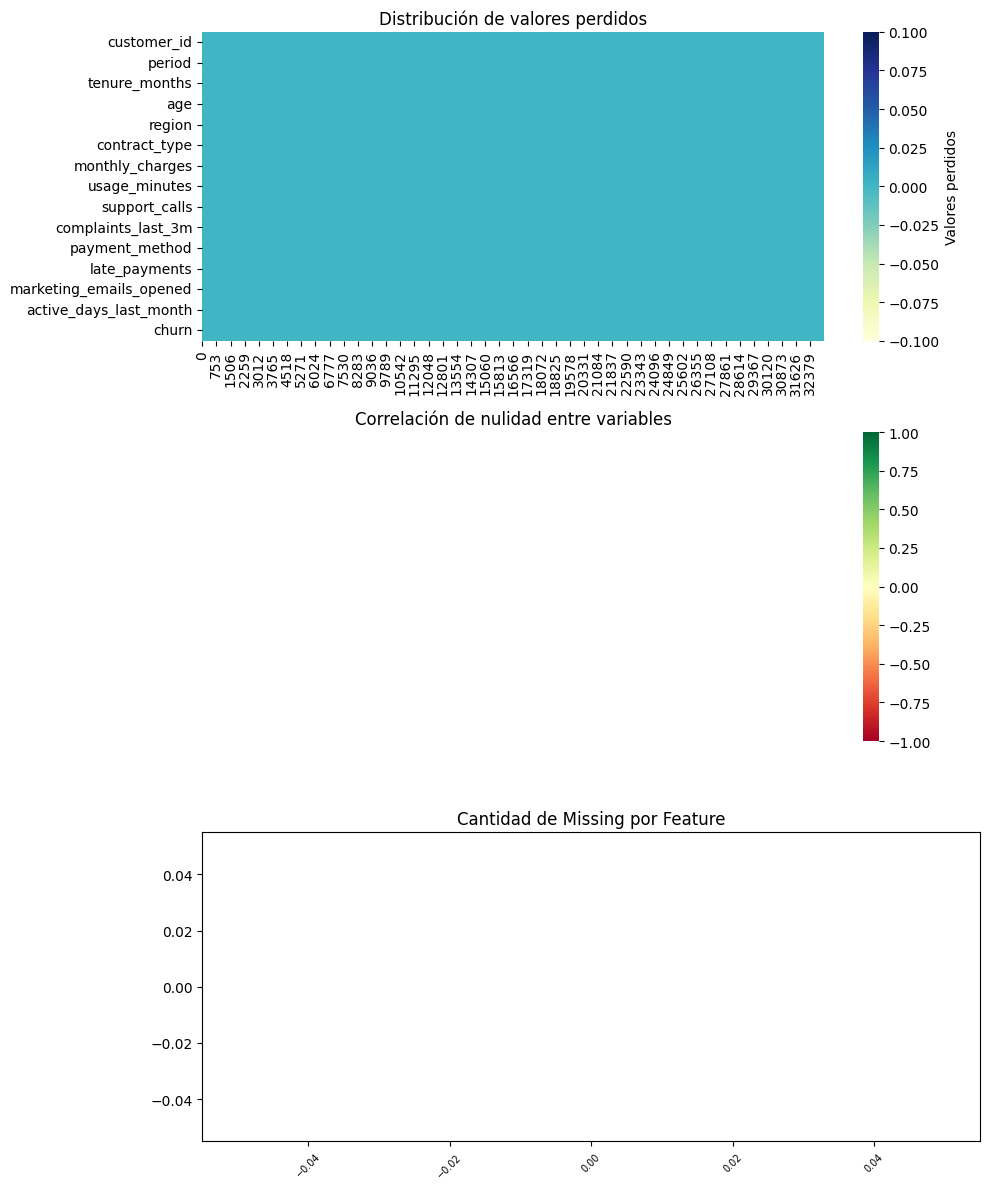

In [21]:
missings_analisis(data= dataframe)

In [ ]:
# outliers
## windsorization (IQR como detección y windsorization como tratamiento) - check
## percentiles (detección y tratamiento) - check
## remover registros (eliminar outliers) - feature engineering
## log transform (creo que esto ya esta en sklearn)
## robust scaler (esto ya esta en sklearn)
## jhonson - feature engineering


In [22]:
def outlier_detect_iqr(data: pd.DataFrame):
    data_numeric = data.select_dtypes(include= 'number')
    semantic_feats = inventario_features(data= data)
    excluir_feat_conteo = semantic_feats.loc[semantic_feats['semantic_dtype'] == 'Conteo']['feature'].to_list()
    data_numeric = data_numeric.drop(excluir_feat_conteo, axis= 1)
    feats = []
    outliers_num_list = []
    outliers_pct_list = []
    lim_sup_list = []
    lim_inf_list = []
    for feat in data_numeric.columns.to_list():
        IQR = data_numeric[feat].quantile(0.75) - data_numeric[feat].quantile(0.25)
        limite_superior = data_numeric[feat].quantile(0.75) + (1.5 * IQR)
        limite_inferior = data_numeric[feat].quantile(0.25) - (1.5 * IQR)
        feats.append(feat)
        lim_inf_list.append(limite_inferior)
        lim_sup_list.append(limite_superior)
        ## Cantidad outliers y %
        outliers_n = (data[feat] > limite_superior).sum() +  (data[feat] < limite_inferior).sum()
        outliers_pct = outliers_n / (data[feat].shape[0])
        outliers_num_list.append(outliers_n)
        outliers_pct_list.append(f'{(outliers_pct * 100):.2f}%')
    
    outliers_iqr = pd.DataFrame({
        'Feature': feats,
        'Límite Superior': lim_sup_list,
        'Límite Inferior': lim_inf_list,
        'Reg. Fuera del Rango': outliers_num_list,
        '% Reg. Fuera del Rango': outliers_pct_list
    }).sort_values(by= 'Reg. Fuera del Rango', ascending= False)

    return outliers_iqr

def outlier_detect_percentil(data: pd.DataFrame):
    data_numeric = data.select_dtypes(include= 'number')
    semantic_feats = inventario_features(data= data)
    excluir_feat_conteo = semantic_feats.loc[semantic_feats['semantic_dtype'] == 'Conteo']['feature'].to_list()
    data_numeric = data_numeric.drop(excluir_feat_conteo, axis= 1)
    rows_data = data_numeric.shape[0]
    feats = []
    p_min_list = []
    p_max_list = []
    registros_fuera_list = []
    registros_fuera_pct_list = []
    p_min_nom_list = []
    p_max_nom_list = []
    if rows_data < 5000:
        for feat in data_numeric.columns.tolist():
            p_min = data_numeric[feat].quantile(0.05)
            p_max = data_numeric[feat].quantile(0.95)
            p_min_nom = 'P5'
            p_max_nom = 'P95'
            feats.append(feat)
            p_min_list.append(round(p_min, 2))
            p_max_list.append(round(p_max, 2))
            registros_fuera = (data_numeric[feat] < p_min).sum() + (data_numeric[feat] > p_max).sum()
            registros_fuera_pct = registros_fuera / (data_numeric[feat].shape[0])
            registros_fuera_list.append(registros_fuera)
            registros_fuera_pct_list.append(f'{(registros_fuera_pct*100):.2f}%')
            p_min_nom_list.append(p_min_nom)
            p_max_nom_list.append(p_max_nom)
    elif rows_data < 100000:
        for feat in data_numeric.columns.tolist():
            p_min = data_numeric[feat].quantile(0.01)
            p_max = data_numeric[feat].quantile(0.99)
            p_min_nom = 'P1'
            p_max_nom = 'P99'
            feats.append(feat)
            p_min_list.append(round(p_min,2))
            p_max_list.append(round(p_max, 2))
            registros_fuera = (data_numeric[feat] < p_min).sum() + (data_numeric[feat] > p_max).sum()
            registros_fuera_pct = registros_fuera / (data_numeric[feat].shape[0])
            registros_fuera_list.append(registros_fuera)
            registros_fuera_pct_list.append(f'{(registros_fuera_pct*100):.2f}%')
            p_min_nom_list.append(p_min_nom)
            p_max_nom_list.append(p_max_nom)
    else:
        for feat in data_numeric.columns.tolist():
            p_min = data_numeric[feat].quantile(0.005)
            p_max = data_numeric[feat].quantile(0.995)
            p_min_nom = 'P0.5'
            p_max_nom = 'P99.5'
            feats.append(feat)
            p_min_list.append(round(p_min,2))
            p_max_list.append(round(p_max,2))
            registros_fuera = (data_numeric[feat] < p_min).sum() + (data_numeric[feat] > p_max).sum()
            registros_fuera_pct = registros_fuera / (data_numeric[feat].shape[0])
            registros_fuera_list.append(registros_fuera)
            registros_fuera_pct_list.append(f'{(registros_fuera_pct*100):.2f}%')
            p_min_nom_list.append(p_min_nom)
            p_max_nom_list.append(p_max_nom)

    df_outlier_percentil = pd.DataFrame({
        'Feature': feats,
        'PCT Min': p_min_nom,
        'Valor PCT minimo': p_min_list,
        'PCT Max': p_max_nom,
        'Valor PCT maximo': p_max_list,
        'Registros fuera': registros_fuera_list,
        '% Registros fuera': registros_fuera_pct_list
    }).sort_values(by= 'Registros fuera', ascending= False)
    return df_outlier_percentil
    

In [23]:
outlier_detect_percentil(dataframe)

,Feature,PCT Min,Valor PCT minimo,PCT Max,Valor PCT maximo,Registros fuera,% Registros fuera
3,usage_minutes,P1,138.19,P99,666.93,664,2.00%
2,monthly_charges,P1,30.36,P99,89.09,656,1.98%
4,active_days_last_month,P1,12.00,P99,35.00,577,1.74%
0,tenure_months,P1,2.00,P99,54.00,470,1.42%
1,age,P1,18.00,P99,68.00,330,1.00%


In [24]:
outlier_detect_iqr(data= dataframe)

,Feature,Límite Superior,Límite Inferior,Reg. Fuera del Rango,% Reg. Fuera del Rango
0,tenure_months,50.500,-9.500,616,1.86%
4,active_days_last_month,37.500,9.500,172,0.52%
3,usage_minutes,797.255,10.575,1,0.00%
1,age,93.500,-6.500,0,0.00%
2,monthly_charges,118.880,1.120,0,0.00%


In [ ]:
# Distribuciones de los features numéricos
# Distribuciones de los features categóricas
# Análisis del Target

In [61]:
def numeric_distributions(data: pd.DataFrame, target_name: str):
    
    ## Distribución y BoxPlot
    data_numeric = data.select_dtypes(include= 'number')
    data_numeric_wo_target = [feat for feat in data_numeric.columns.to_list() if feat != 'churn']
    fig, ax = plt.subplots(nrows=len(data_numeric_wo_target) , ncols=3, figsize = (10, 25))
    for i, var in enumerate(data_numeric_wo_target):
        ax[i,0].hist(
            data_numeric[var],
            bins = 30
            #color='tab:blue'
        )
        ax[i, 0].set_title(f'Distribución de {var}', fontsize = 9)
        ax[i, 0].tick_params(axis= 'x', labelsize = 9)
        ax[i, 0].tick_params(axis = 'y', labelsize = 9)

        sns.boxplot(
            data = data_numeric,
            x = target_name,
            y = var,
            ax= ax[i,2]
            #orient = 'v'
            
        )
        ax[i,2].set_title(f'Boxplot {var}', fontsize = 9)
        ax[i,2].tick_params(axis='x', labelsize = 9)
        ax[i,2].tick_params(axis='y', labelsize = 9)
        ax[i,2].set_xlabel("")
        ax[i,2].set_ylabel("")

        df_tmp = data_numeric.copy()
        df_tmp['bin'] = pd.qcut(
            x= data_numeric[var],
            q= 10,
            duplicates= 'drop'
        )
        agg = df_tmp.groupby(
            ['bin']
        ).agg(
            event_rate = (target_name, 'mean')
        ).reset_index(level= 0, drop= False)
        agg['bin'] = agg['bin'].astype(str)
        
        sns.lineplot(
            data= agg,
            ax= ax[i,1],
            x= 'bin',
            y= 'event_rate',
            markers= 'o',
            
        )
        ax[i,1].set_title(f'Relación {var} vs Target Rate', fontsize = 9)
        ax[i,1].tick_params(axis = 'x', labelsize = 9, labelrotation= 34)
        ax[i,1].tick_params(axis = 'y', labelsize = 9)
        ax[i,1].set_xlabel("")
        ax[i,1].set_ylabel("Target Rate", fontsize = 9)
        
    plt.suptitle('Distribución, BoxPlot y Relación con el Target', y= 1.0001)
    plt.tight_layout()

    return plt.show()


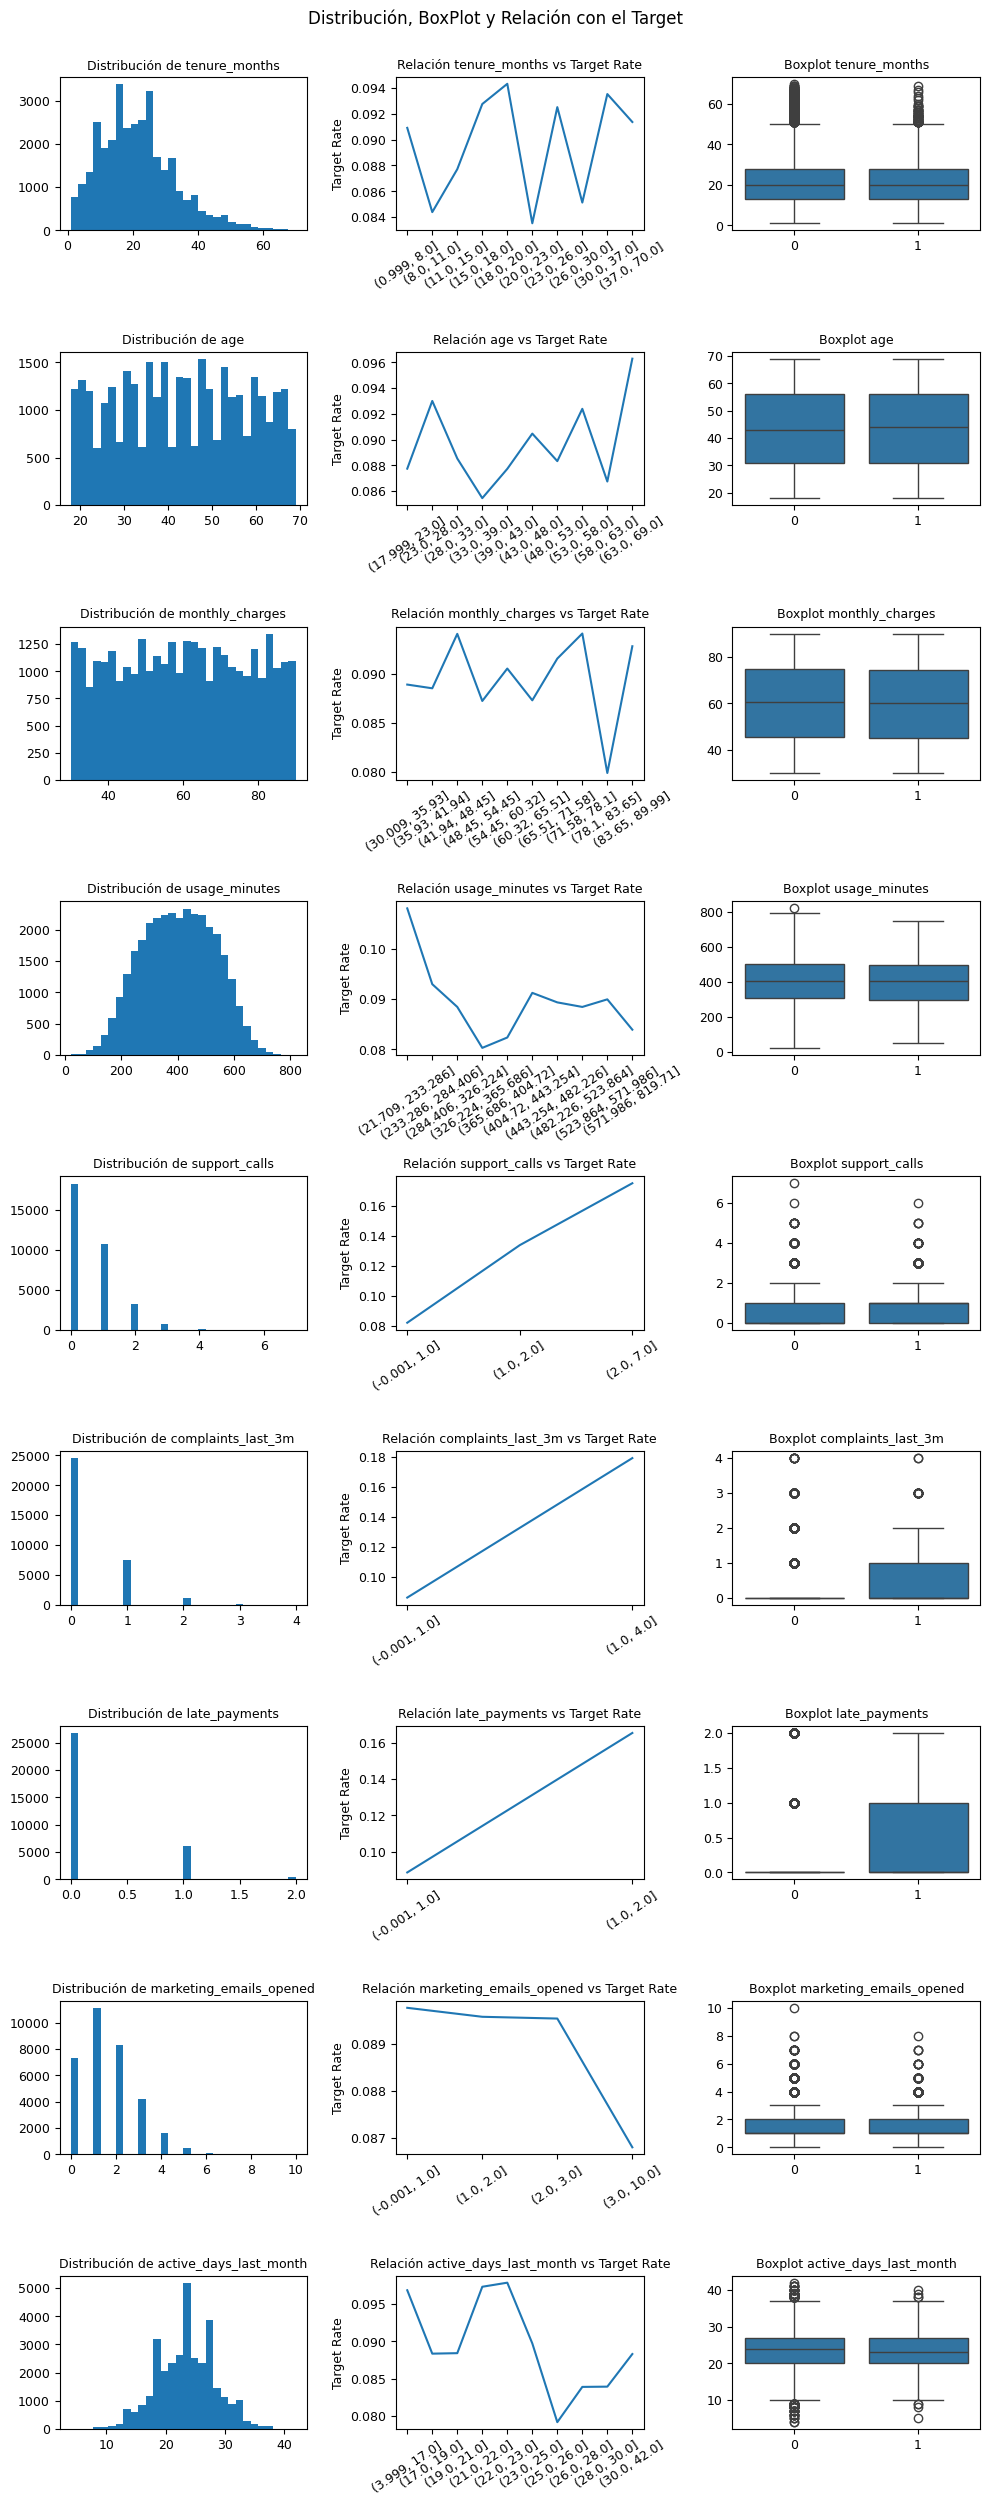

In [62]:
numeric_distributions(data= dataframe, target_name= 'churn')

In [68]:
# Distribuciones de los features categóricas
def categorical_distributions(data: pd.DataFrame, target_name: str, exclude: list = []):
    data_categorical = data.copy()
    data_categorical = data_categorical.select_dtypes(include= ['string', 'object', 'category'])
    data_categorical_w_target = pd.concat([data_categorical, data[target_name]], axis= 1)
    feats_categoricas = [feat for feat in data_categorical.columns.to_list() if feat not in exclude]
    fig, ax = plt.subplots(nrows= len(feats_categoricas) , ncols=2, figsize = (8, 13))
    for i, var in enumerate(feats_categoricas):
        agg = data_categorical_w_target.groupby(
            [var]
        ).agg(
            mean_target = (target_name, 'mean'),
            count_var = (var, 'count')
        ).reset_index(level=0, drop= False).sort_values(by= 'mean_target', ascending= True)
        
        ax[i,0].plot(
            agg[var],
            agg['mean_target'],
            marker = 'o'
        )
        ax[i,0].tick_params(axis = 'x', labelsize = 7, rotation = 45)
        ax[i,0].tick_params(axis = 'y', labelsize = 7)
        ax[i,0].set_title(f'Feature {var} vs Target Rate', fontsize = 11)

        agg = agg.sort_values(by= 'count_var', ascending = False)
        bar = ax[i,1].bar(
            agg[var],
            agg['count_var'],
        )
        ax[i,1].bar_label(bar, fontsize = 9)
        ax[i,1].set_title(f'Distribución de {var}', fontsize = 11)
        ax[i,1].tick_params(axis = 'x', labelsize = 9, rotation = 45)
        ax[i,1].tick_params(axis = 'y', labelsize = 9)
    plt.tight_layout()

    return plt.show()



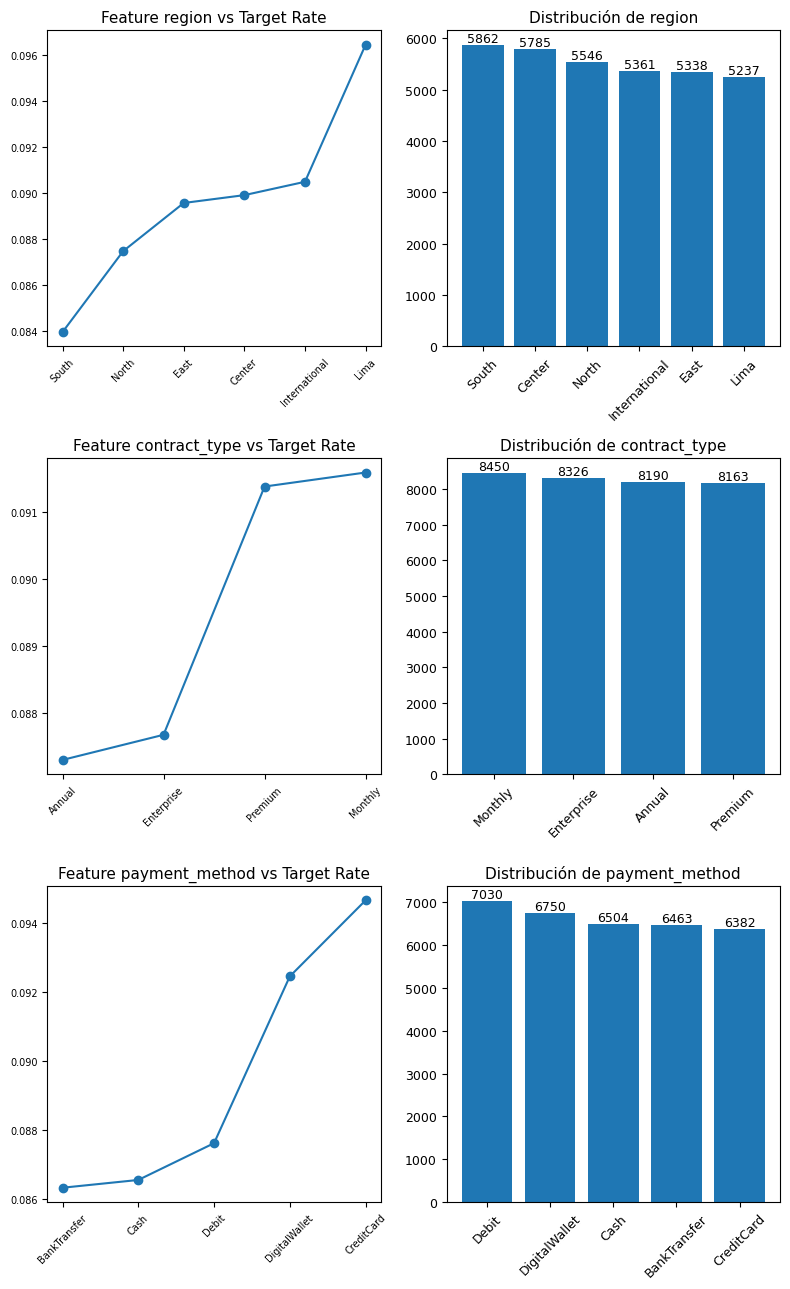

In [69]:
categorical_distributions(dataframe, target_name= 'churn', exclude= ['customer_id'])

In [ ]:
# Análisis del Target (para Panel Temporal) - Dejar para después en otro tipo de EDA
def target_analisis(data: pd.DataFrame):


    fig, ax = plt.subplots(3, 1, figsize = (9, 9))
    ax[0].bar(
        agg_period_2023_2024['period'],
        agg_period_2023_2024['n_registros'],
        color = 'steelblue',
        width= 20,
        label = '2023-2024'
    )

    ax[0].bar(
        agg_period_2025['period'],
        agg_period_2025['n_registros'],
        width = 20,
        color = 'orange',
        label = '2025'
    )

    ax[0].bar(
        agg_period_2026['period'],
        agg_period_2026['n_registros'],
        width = 20,
        color = 'tomato',
        label = '2026'
    )
    ax[0].set_ylabel('Record count', fontsize = 9)
    ax[0].tick_params(axis = 'y', labelsize = 8)
    ax[0].tick_params(axis = 'x', labelbottom = False)
    ax[0].set_title(f'Cantidad de Registros por Período', fontsize = 10)
    ax[0].legend(fontsize = 9)

    ## Gráfico 2
    ax[1].plot(
        agg_period_2023_2024['period'],
        agg_period_2023_2024['target_mean'],
        color = 'steelblue',
        #marker = 'o'
    )
    ax[1].axhline(
        y = media_2023_2024,
        color = 'steelblue',
        linestyle = '--',
        linewidth= 2,
        label = f'Promedio de {round(media_2023_2024,3)} (2023-2024)'
    )

    ax[1].plot(
        agg_period_2025['period'],
        agg_period_2025['target_mean'],
        color = 'orange',
        #marker = 'o'
    )

    ax[1].axhline(
        y = media_2025,
        color = 'orange',
        linestyle = '--',
        linewidth = 2,
        label = f'Promedio de {round(media_2025, 3)} (2025)'
    )

    ax[1].plot(
        agg_period_2026['period'],
        agg_period_2026['target_mean'],
        color = 'tomato'
    )

    ax[1].axhline(
        y = media_2026,
        color = 'tomato',
        linestyle = '--',
        linewidth = 2,
        label = f'Promedio de {round(media_2026, 3)} (2026)'
    )

    ax[1].set_title('Churn Rate por Período', fontsize = 10)
    ax[1].set_ylabel('Churn Rate Promedio', fontsize = 9)
    ax[1].tick_params(axis = 'x', labelsize = 8, rotation = 45)
    ax[1].tick_params(axis = 'y', labelsize = 8)
    ax[1].legend(fontsize = 9)

    ## Gráfico 3
    
    categorias = ['2023-2024 (Train)', '2025 (Test)', '2026 (OOT)']
    x = np.arange(len(categorias))
    width = 0.25

    serie_event_rate = [event_rate_2023_2024, event_rate_2025, event_rate_2026]
    serie_no_event_rate = [no_event_rate_2023_2024, no_event_rate_2025, no_event_rate_2026]

    bar_1 = ax[2].bar(
        x - width/2,
        serie_event_rate,
        width,
        label = 'Event Rate'
    )

    bar_2 = ax[2].bar(
        x + width/2,
        serie_no_event_rate,
        width,
        label = 'No Event Rate'
    )
    ax[2].bar_label(bar_1, labels = [f'{d:.2%}' for d in serie_event_rate], fontsize = 9)
    ax[2].bar_label(bar_2, labels = [f'{d:.2%}' for d in serie_no_event_rate], fontsize = 9)

    ax[2].set_xticks(x)
    ax[2].set_xticklabels(categorias)
    ax[2].set_title('Distribución del Target por Período', fontsize = 10, y = 1.05)
    ax[2].tick_params(axis = 'x', labelsize = 9)
    ax[2].tick_params(axis = 'y', labelsize = 9)

    plt.tight_layout()

    fig.savefig(
        '../artifacts/eda/figures/analisis_target.png',
        dpi = 300,
        bbox_inches = 'tight',
        facecolor = 'white'
    )

    plt.show()

In [ ]:
def analisis_target(data: pd.DataFrame, target_name: str):
    data_df = data.copy()
    fig, ax = plt.subplots(nrows= 1, ncols= 2, figsize = (7, 4))
    bars = ax[0].bar(
        x = [0, 1],
        height= data_df[target_name].value_counts(),
        color = ["steelblue", "tomato"]
    )

    ax[0].bar_label(bars, fmt = "%d")
    ax[0].set(title = 'Conteo del Target', ylabel = 'Cantidad', xlabel = 'Target')
    ax[0].set_xticks([0, 1])

    ax[1].pie(
        x = data_df[target_name].value_counts().reindex([0, 1], fill_value= 0),
        labels = ["No default", "Default"],
        colors = ["steelblue", "tomato"],
        autopct = "%.0f%%",
        startangle = 90
    )
    ax[1].set_title("Distribución del target")

    plt.tight_layout()
    plt.close(fig)

    # Registros
    n_registros = data_df[target_name].count()
    
    # Missing target
    missing_target = data_df[target_name].isnull().sum()

    # Clases únicas
    number_of_class = data_df[target_name].nunique()

    # Positive Rate
    positive_rate = data_df[target_name].mean()

    # Negative Rate
    negative_rate = (data_df[target_name] == 0).mean()

    # Imbalance ratio
    imbalance_ratio = f'{(negative_rate / positive_rate):.2f}:1'                         

    # Baseline accuracy
    baseline_accuracy = f'{(negative_rate*100):.2f}%'

    # Nivel de desbalance
    if positive_rate < 0.05:
        level_imbalance = 'Muy Desbalanceado'
    elif positive_rate < 0.20:
        level_imbalance = 'Desbalanceado'
    elif positive_rate < 0.45:
        level_imbalance = 'Moderadamente desbalanceado'
    else:
        level_imbalance = 'Balanceado'

    target_analisis_df = pd.DataFrame([{
        'Registros': n_registros,
        'Missing target': missing_target,
        'Clases únicas': number_of_class,
        'Positive rate': positive_rate,
        'Negative rate': negative_rate,
        'Imbalance rate': imbalance_ratio,
        'Baseline accuracy': baseline_accuracy,
        'Nivel de desbalance': level_imbalance
    }])

    return fig, target_analisis_df


In [125]:
fig, target_analysis = analisis_target(data= dataframe, target_name='churn')

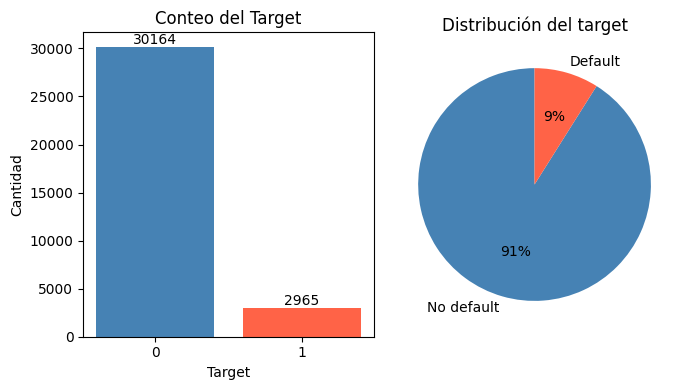

In [126]:
display(fig)

In [129]:
target_analysis

,Registros,Missing target,Clases únicas,Positive rate,Negative rate,Imbalance rate,Baseline accuracy,Nivel de desbalance
0,33129,0,2,0.089499,0.910501,10.17:1,91.05%,Desbalanceado


In [79]:
(dataframe['churn'] == 1).mean() / (dataframe['churn'] == 0).mean()

np.float64(0.0982959819652566)

In [134]:
def information_value(data: pd.DataFrame, target_name: str):
        """Retorna una tabla resumen del IV de cada feature numérica"""
        df = data.copy()
        data_numeric = df.select_dtypes(include= 'number').drop([target_name], axis= 1)
        lista_iv = []
        lista_bins = []

        for i in data_numeric.columns:
            df['bins'], bins = pd.qcut(
                x = df[i],
                q = 5,
                retbins= True,
                duplicates= 'drop'
            )
            eps = 1e-5
            table = df.groupby(
                ['bins'], observed=False
            ).agg(
                total_obs = (target_name, "count"),
                total_event = (target_name, "sum"),
                event_rate = (target_name, "mean")
            )
            table['total_no_event'] = table["total_obs"] - table["total_event"]
            table['no_event_rate'] = table['total_no_event'] / table['total_obs']
            table['dist_event'] = table['total_event'] / table['total_event'].sum()
            table['dist_no_event'] = table['total_no_event'] / table['total_no_event'].sum()
            table['woe'] = (
                np.log(
                    (table['dist_no_event'] + eps) / (table['dist_event'] + eps)
                )
            )
            table = table.reset_index(level= 0, drop= False)
            table['information_value_calculation'] = ((table['dist_no_event'] - table['dist_event']) * (table['woe']))
            iv = (table['information_value_calculation'].sum())
            #print(table['woe'].count())
            lista_iv.append(iv)
            lista_bins.append(bins)
        
        df_iv = pd.DataFrame({
            'Feature': data_numeric.columns.to_list(),
            'Information Value': lista_iv
        }).sort_values(by= 'Information Value', ascending= False)

        return df_iv, lista_bins

In [135]:
# Correlaciones (pearson, spearman)
def eda_relaciones_feats_numericas(data: pd.DataFrame, target_name: str):

    corr = data.corr('pearson', numeric_only= True)
    mask = np.triu(
        np.ones_like(corr, dtype= bool)
    )
    fig, ax = plt.subplots(nrows= 5, ncols= 1, figsize = (6, 16))
    # Gráfico 1: Correlación Pearson
    sns.heatmap(
        data= corr,
        mask= mask,
        ax= ax[0],
        annot= True,
        cmap= 'coolwarm',
        square= False,
        fmt = '.2f',
        annot_kws= {
            'fontsize': 8
        }
    )
    ax[0].set_title('Correlación de Pearson', fontsize = 10)
    ax[0].tick_params(axis = 'x', labelsize = 7)
    ax[0].tick_params(axis = 'y', labelsize = 7)

    ## Gráfico 2: Correlación Spearman

    corr_spearman = data.corr('spearman', numeric_only= True)
    mask_spearman = np.triu(
        np.ones_like(corr_spearman, dtype= bool)
    )

    sns.heatmap(
        data= corr_spearman,
        mask= mask_spearman,
        cmap= 'coolwarm',
        annot = True,
        annot_kws= {
            'fontsize': 8
        },
        fmt= '.2f',
        ax= ax[1]
    )
    ax[1].set_title('Correlación de Spearman', fontsize = 10)
    ax[1].tick_params(axis = 'x', labelsize = 7)
    ax[1].tick_params(axis = 'y', labelsize = 7)

    ## Gráfico 3: Mutual information

    ## Entrenamiento de MI
    data_numeric = data.select_dtypes(include='number').drop([target_name], axis= 1)
    mi_scores = mutual_info_classif(
    X= data_numeric,
    y= data[target_name],
    discrete_features= 'auto',
    n_neighbors= 3,
    random_state= 42
    )
    mi_df = pd.DataFrame({
        'feature': data_numeric.columns,
        'mutual_info': mi_scores
    }).sort_values(by= 'mutual_info', ascending = False).reset_index(level=0, drop= False)


    ax[2].barh(
        mi_df['feature'][::-1],
        mi_df['mutual_info'][::-1]
    )
    ax[2].set_title('Mutual Information', fontsize = 10)
    ax[2].tick_params(axis = 'x', labelsize = 7)
    ax[2].tick_params(axis = 'y', labelsize = 7)

    ## Gráfico 4: VIF

    ## Entrenamiento del VIF
    vif_df = pd.DataFrame({
    'feature': data_numeric.columns,
    'VIF': [
        variance_inflation_factor(data_numeric.values, i)
        for i in range(data_numeric.shape[1])
    ]
    }).sort_values(by= 'VIF', ascending = False)

    ax[3].barh(
        vif_df['feature'][::-1],
        vif_df['VIF'][::-1]
    )
    ax[3].set_title('Análisis del VIF', fontsize = 10)
    ax[3].tick_params(axis = 'x', labelsize = 7)
    ax[3].tick_params(axis = 'y', labelsize = 7)
    ax[3].axvline(
        x = 5,
        linestyle = '--',
        color = 'tomato',
        linewidth = 2
    )

    ## Gráfico 5: IV
    df_iv, lista_bins = information_value(data= data, target_name= target_name)
    ax[4].barh(
        df_iv['Feature'][::-1],
        df_iv['Information Value'][::-1]
    )
    ax[4].set_title('Information Value de las Features', fontsize = 10)
    ax[4].tick_params(axis = 'x', labelsize = 7)
    ax[4].tick_params(axis = 'y', labelsize = 7)
    ax[4].axvline(
        x = 0.1,
        color = 'tomato',
        linestyle = '--',
        linewidth = 2
    )

    plt.tight_layout()
    plt.close(fig)
    return fig

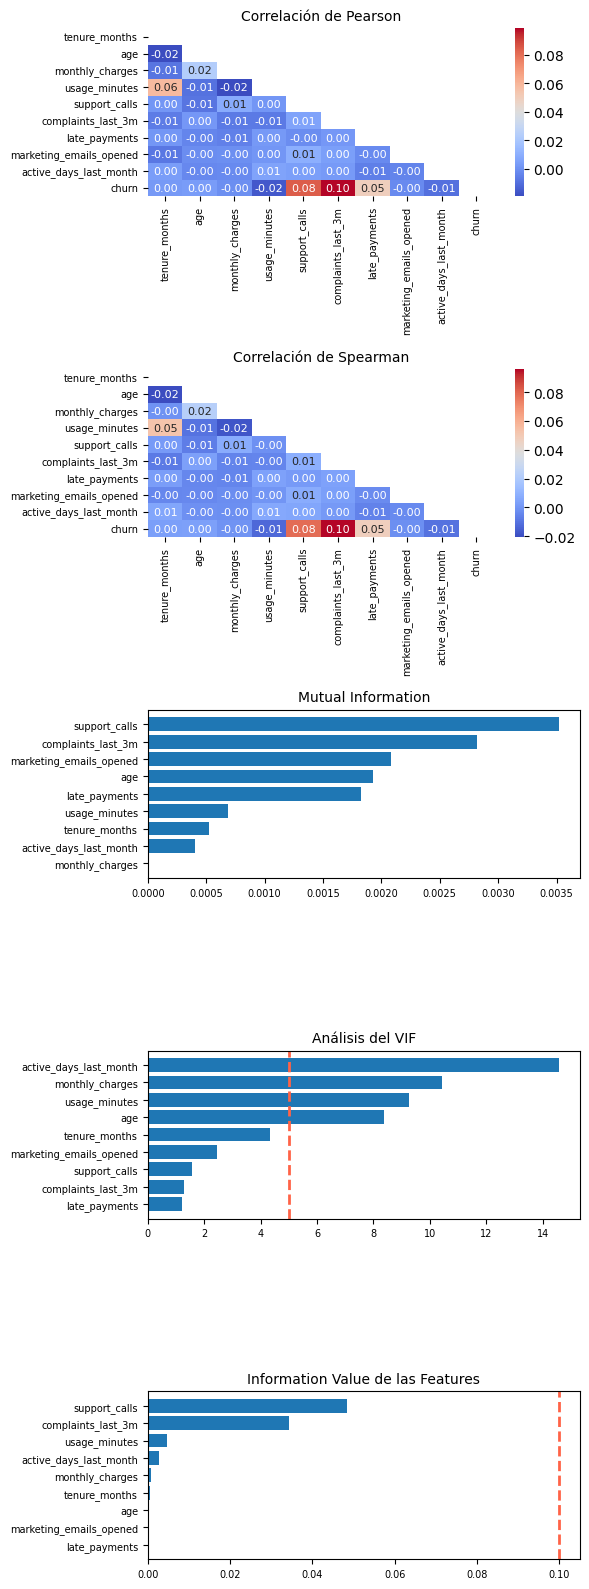

In [136]:
fig = eda_relaciones_feats_numericas(data= dataframe, target_name= 'churn')
fig

In [ ]:
# PSI de negocio

In [10]:
EPSILON = 1e-6


def calculate_psi(expected, actual):
    """
    Calcula el PSI a partir de dos distribuciones.
    expected y actual deben ser arrays de proporciones.
    """
    expected = np.clip(expected, EPSILON, None)
    actual = np.clip(actual, EPSILON, None)

    return np.sum((actual - expected) * np.log(actual / expected))

def interpret_psi(psi):

    if psi < 0.10:
        return "Sin drift"

    elif psi < 0.25:
        return "Drift moderado"

    else:
        return "Drift severo"

def psi_numeric(train, test, bins=10):
    """
    PSI para variables numéricas usando cuantiles del Train.
    """

    # bins usando el Train
    cut_points = np.unique(
        np.quantile(train.dropna(), np.linspace(0, 1, bins + 1))
    )

    train_bins = pd.cut(
        train,
        bins=cut_points,
        include_lowest=True,
        duplicates="drop"
    )

    test_bins = pd.cut(
        test,
        bins=cut_points,
        include_lowest=True,
        duplicates="drop"
    )

    train_dist = (
        train_bins.value_counts(normalize=True)
        .sort_index()
    )

    test_dist = (
        test_bins.value_counts(normalize=True)
        .reindex(train_dist.index, fill_value=0)
    )

    psi = calculate_psi(
        train_dist.values,
        test_dist.values
    )

    return psi


def psi_categorical(train, test):
    """
    PSI para variables categóricas.
    """

    train_dist = (
        train.fillna("MISSING")
        .value_counts(normalize=True)
    )

    test_dist = (
        test.fillna("MISSING")
        .value_counts(normalize=True)
    )

    categories = train_dist.index.union(test_dist.index)

    train_dist = train_dist.reindex(categories, fill_value=0)
    test_dist = test_dist.reindex(categories, fill_value=0)

    psi = calculate_psi(
        train_dist.values,
        test_dist.values
    )

    return psi


def dataframe_psi(train_df, test_df):
    """
    Calcula PSI para todas las columnas.
    """

    results = []

    for col in train_df.columns:

        if pd.api.types.is_numeric_dtype(train_df[col]):
            psi = psi_numeric(
                train_df[col],
                test_df[col]
            ).round(4)
            var_type = "numeric"
            interpretacion = interpret_psi(psi= psi)

        else:
            psi = psi_categorical(
                train_df[col],
                test_df[col]
            ).round(4)
            var_type = "categorical"
            interpretacion = interpret_psi(psi= psi)

        results.append({
            "feature": col,
            "type": var_type,
            "psi": psi,
            "interpretacion": interpretacion
        })

    results = (
        pd.DataFrame(results)
        .sort_values("psi", ascending=False)
        .reset_index(drop=True)
    )

    return results

In [11]:
psi_table = dataframe_psi(
    train_df= df_train,
    test_df= df_test
)

psi_table

,feature,type,psi,interpretacion
0,period,categorical,22.2075,Drift severo
1,tenure_months,numeric,9.9611,Drift severo
2,customer_id,categorical,5.7489,Drift severo
3,usage_minutes,numeric,0.0494,Sin drift
4,monthly_charges,numeric,0.0408,Sin drift
5,payment_method,categorical,0.0277,Sin drift
6,age,numeric,0.0204,Sin drift
7,region,categorical,0.0174,Sin drift
8,active_days_last_month,numeric,0.0070,Sin drift
9,contract_type,categorical,0.0036,Sin drift


In [51]:
## Esto ya es parte del Feature Engineering
def outlier_tratamiento_iqr(data: pd.DataFrame):
    ## winsorizar por método IRQ o por percentil
    pass
## otra función para eliminar esos outliers
## otra función para transformarlos

In [181]:
dataframe['age'].quantile(0.9)

np.float64(63.0)

In [205]:
dataframe['complaints_last_3m'].unique()

array([0, 1, 2, 3, 4])

In [172]:
dataframe['age'].shape

(33129,)

In [169]:
dataframe['age'].quantile(0.01)

np.float64(18.0)

In [170]:
dataframe['age'].quantile(0.01)

np.float64(18.0)

In [167]:
dataframe['age'].max()

np.int64(69)

In [ ]:
missing_list = dataframe.columns.tolist()
cant_missing = [dataframe[feat].isnull().sum() for feat in dataframe.columns.tolist()]
data_missing = pd.DataFrame({
    'feat': missing_list,
    'cant_missing': cant_missing
})
data_missing = data_missing.iloc[data_missing['cant_missing']> 0].sort_values(by= 'cant_missing', ascending= False)
data_missing

,feat,cant_missing


In [131]:
dataframe['period'].nunique()

48

In [129]:
dataframe['period'].dtype.name

'datetime64[us]'

In [13]:
data_overview(dataframe, target_name= 'churn', tipo_problema= 'clasificacion churn')

,Data Overview
Filas,33129
Columnas,15
Features Numéricas,10
Features Categóricas,4
Features Datetime,1
Features Booleanas,0
Missing Global (%),0
Features con Missing,0
Features > 20% Missing,0
Filas Duplicadas,0


In [101]:
fecha_max = dataframe.select_dtypes(
    include= 'datetime'
).iloc[:,0].max() 


fecha_min = dataframe.select_dtypes(
    include= 'datetime'
).iloc[:,0].min()

periodos = (
        (fecha_max.year - fecha_min.year) * 12 +
        (fecha_max.month - fecha_min.month) + 1
    )
periodos

48

In [100]:
(fecha_max.year - fecha_min.year)

-3

In [ ]:
target_rate = f'{(data[target_name].mean()*100):.2f}%'

In [75]:
TARGET = 'churn'
dataframe[TARGET].mean()*100
target_rate = f'{(dataframe[TARGET].mean()*100):.2f}%'
target_rate

'8.95%'

In [70]:
(dataframe.select_dtypes(
    include= ['string', 'category', 'object']
).nunique()>20).sum()

np.int64(1)

In [59]:
### missing global
(dataframe.isnull().sum()>0).sum()


np.int64(0)

In [61]:
dataframe.duplicated().sum()

np.int64(0)

In [54]:
dataframe.isna().mean().mean()

np.float64(0.0)

In [11]:
# features numericas
#dataframe.dtypes.value_counts().index.astype(str)
dataframe.dtypes.value_counts().values



# features categoricas

# features datetime

# features booleanas

array([8, 4, 2, 1])

In [48]:
dataframe.select_dtypes(
    include='datetime'
).shape[1]

1

In [41]:
vc = dataframe.dtypes.value_counts()
print(vc.index)
print(type(vc.index[0]))

Index([int64, str, float64, datetime64[us]], dtype='object')
<class 'numpy.dtypes.Int64DType'>


In [43]:
dataframe.dtypes.astype(str).value_counts()['int64']

np.int64(8)

In [45]:
dataframe.dtypes.astype(str).str.contains('datetime').sum()

np.int64(1)

In [25]:
dataframe.dtypes.astype(str).loc['period']

'datetime64[us]'